Type of pd: <class 'module'>
Type of pd.read_csv: <class 'function'>
Pandas version: 2.2.2
CSV loaded successfully.


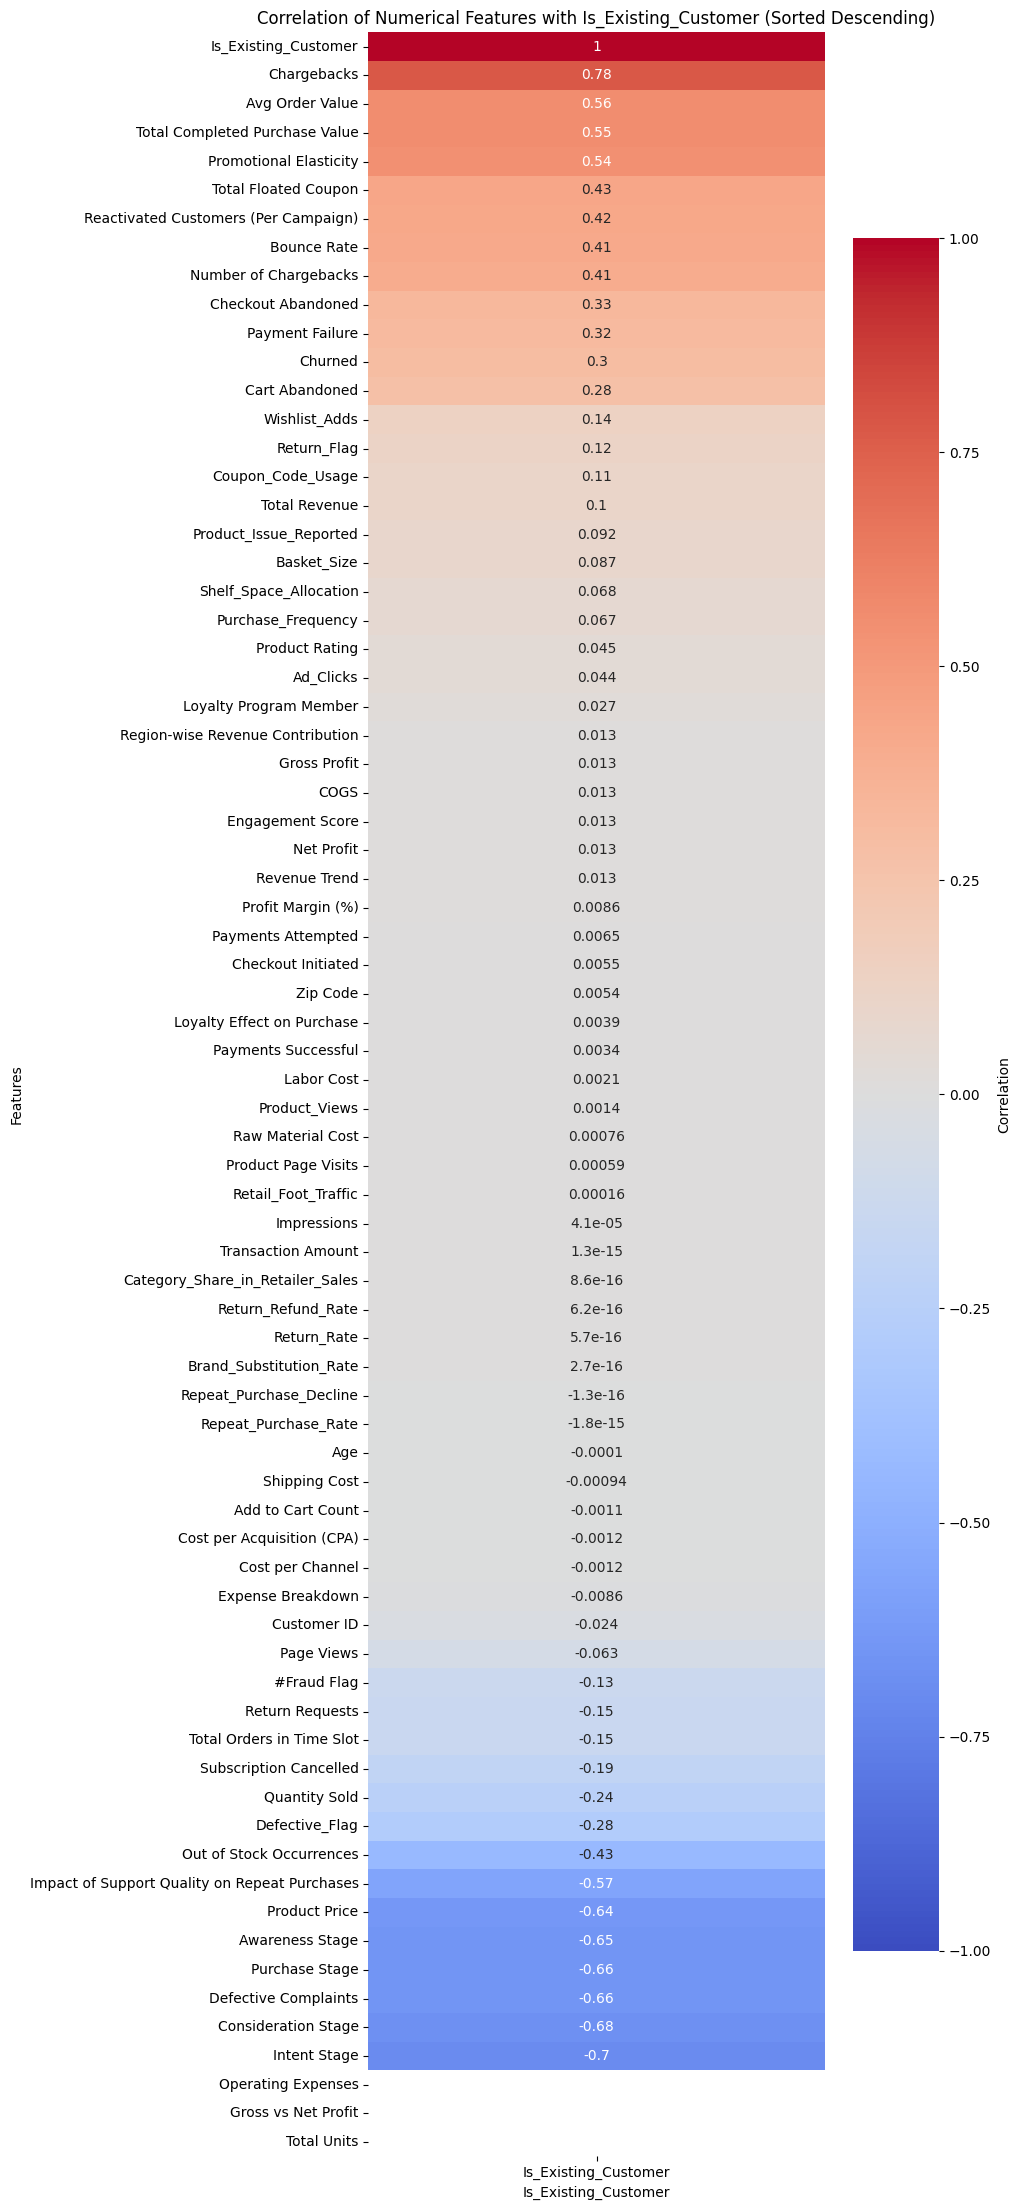


Columns heavily correlated with Is_Existing_Customer (|corr| > 0.5):
Is_Existing_Customer                             1.000
Chargebacks                                      0.777
Avg Order Value                                  0.556
Total Completed Purchase Value                   0.555
Promotional Elasticity                           0.540
Impact of Support Quality on Repeat Purchases   -0.567
Product Price                                   -0.636
Awareness Stage                                 -0.649
Purchase Stage                                  -0.656
Defective Complaints                            -0.656
Consideration Stage                             -0.675
Intent Stage                                    -0.701
Name: Is_Existing_Customer, dtype: float64

Mutual Information Scores (Sorted Descending):
Customer ID                   0.501
Cost per Channel              0.486
Cost per Acquisition (CPA)    0.483
Loyalty Effect on Purchase    0.475
Expense Breakdown             0.474

In [2]:
# Explicitly import pandas to avoid conflicts
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



# Load the dataset
df = pd.read_csv('formatting_data.csv')

# Convert 'Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Create a binary column for "existing customer" based on transaction count
transaction_counts = df.groupby('Customer ID')['Transaction Date'].count().reset_index()
transaction_counts['Is_Existing_Customer'] = (transaction_counts['Transaction Date'] > 1).astype(int)
df = df.merge(transaction_counts[['Customer ID', 'Is_Existing_Customer']], on='Customer ID', how='left')

# Select all numerical columns for analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Is_Existing_Customer' not in numerical_cols:
    numerical_cols.append('Is_Existing_Customer')

# Handle missing values by filling with median for numerical columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# --- Correlation Matrix ---
# Compute correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Extract correlations with 'Is_Existing_Customer' and sort in descending order
existing_customer_corrs = correlation_matrix['Is_Existing_Customer'].sort_values(ascending=False)

# Create a DataFrame for visualization
corr_df = pd.DataFrame(existing_customer_corrs).T

# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, len(existing_customer_corrs) * 0.3))
sns.heatmap(corr_df.T, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation of Numerical Features with Is_Existing_Customer (Sorted Descending)')
plt.xlabel('Is_Existing_Customer')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print heavily correlated columns (|corr| > 0.5)
heavily_correlated = existing_customer_corrs[abs(existing_customer_corrs) > 0.5]
print("\nColumns heavily correlated with Is_Existing_Customer (|corr| > 0.5):")
print(heavily_correlated.round(3))

# --- Mutual Information ---
# Prepare data
X = df[numerical_cols].drop(columns=['Is_Existing_Customer'])
y = df['Is_Existing_Customer']

# Compute mutual information scores
try:
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    print("\nMutual Information Scores (Sorted Descending):")
    print(mi_scores.round(3))
except Exception as e:
    print(f"Error computing Mutual Information: {e}")

# --- Permutation Importance ---
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Compute permutation importance
try:
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    perm_scores = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)
    print("\nPermutation Importance Scores (Sorted Descending):")
    print(perm_scores.round(3))
except Exception as e:
    print(f"Error computing Permutation Importance: {e}")

# Highlight top 5 features for each method
print("\nTop 5 Features by Correlation:")
print(existing_customer_corrs.head(5).round(3))
print("\nTop 5 Features by Mutual Information:")
print(mi_scores.head(5).round(3))
print("\nTop 5 Features by Permutation Importance:")
print(perm_scores.head(5).round(3))

# **Correaltion with AOV**

Top 5 Positive Correlations with Avg Order Value:
Total Revenue        0.046224
Product Rating       0.014989
Profit Margin (%)    0.009932
Net Profit           0.005231
Gross Profit         0.005231
Name: Avg Order Value, dtype: float64

Top 5 Negative Correlations with Avg Order Value:
Add to Cart Count    -0.003272
Page Views           -0.029542
Quantity Sold        -0.358605
Operating Expenses         NaN
Total Units                NaN
Name: Avg Order Value, dtype: float64


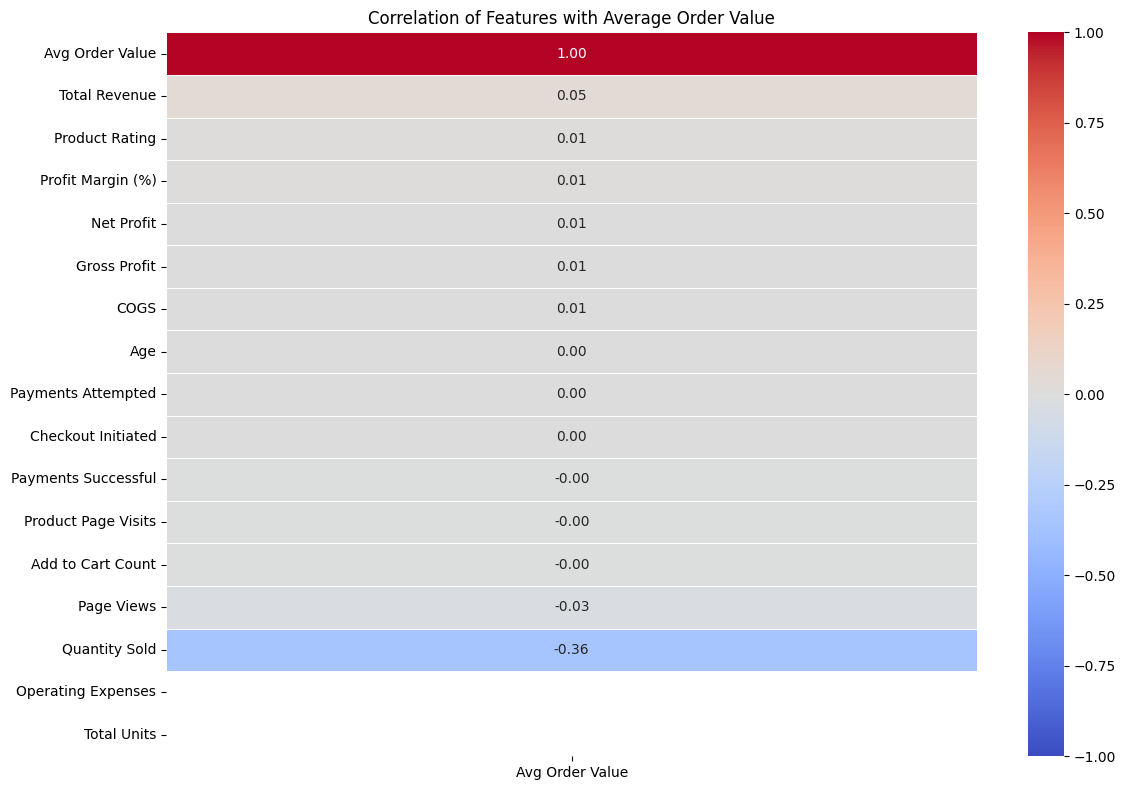

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure matplotlib displays inline
%matplotlib inline

# Loading the dataset (assuming it's accessible as a file)
data = pd.read_csv('formatting_data.csv')

# Selecting numerical columns for correlation analysis
numerical_columns = [
    'Avg Order Value', 'Age', 'Page Views', 'Product Rating',
    'Total Revenue', 'Gross Profit', 'Net Profit', 'COGS',
    'Operating Expenses', 'Profit Margin (%)', 'Product Page Visits',
    'Add to Cart Count', 'Checkout Initiated', 'Payments Attempted',
    'Payments Successful', 'Quantity Sold', 'Total Units'
]

# Ensuring the selected columns exist in the dataset
numerical_columns = [col for col in numerical_columns if col in data.columns]

# Converting columns to numeric, handling errors by coercing to NaN
for col in numerical_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Dropping rows with NaN values in the selected columns
data_clean = data[numerical_columns].dropna()

# Calculating the correlation matrix
correlation_matrix = data_clean.corr()

# Extracting correlations with 'Avg Order Value'
avg_order_corr = correlation_matrix['Avg Order Value'].sort_values(ascending=False)

# Printing the top 5 positive and top 5 negative correlations
print("Top 5 Positive Correlations with Avg Order Value:")
print(avg_order_corr.head(6)[1:])  # Excluding self-correlation
print("\nTop 5 Negative Correlations with Avg Order Value:")
print(avg_order_corr.tail(5))

# Creating a heatmap for correlations with 'Avg Order Value'
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix[['Avg Order Value']].sort_values(by='Avg Order Value', ascending=False),
    annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', linewidths=0.5
)
plt.title('Correlation of Features with Average Order Value')
plt.tight_layout()
plt.show()

Pandas version: 2.2.2


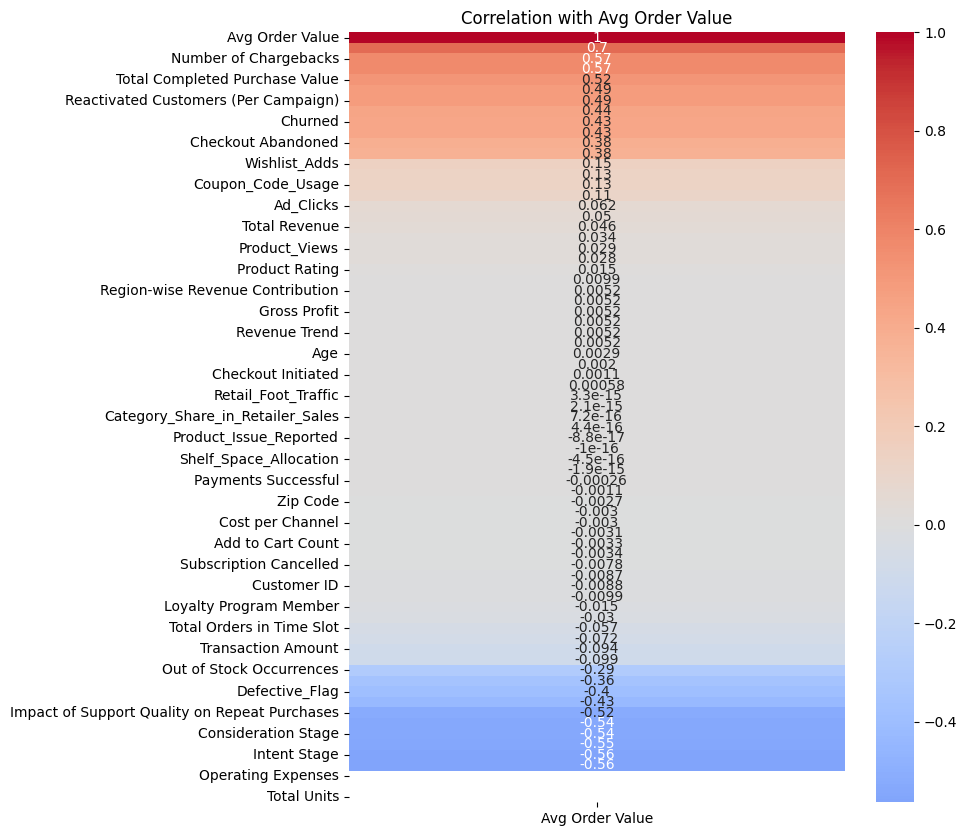


Strong Correlations (|corr| > 0.5):
Avg Order Value                                  1.000
Chargebacks                                      0.705
Number of Chargebacks                            0.574
Bounce Rate                                      0.574
Total Completed Purchase Value                   0.522
Impact of Support Quality on Repeat Purchases   -0.523
Awareness Stage                                 -0.537
Consideration Stage                             -0.543
Purchase Stage                                  -0.547
Intent Stage                                    -0.558
Product Price                                   -0.564
Name: Avg Order Value, dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



Mutual Information Scores:
Total Completed Purchase Value    1.083
Loyalty Effect on Purchase        0.841
Bounce Rate                       0.800
Product Price                     0.795
Promotional Elasticity            0.775
                                  ...  
Loyalty Program Member            0.033
Gross vs Net Profit               0.013
Operating Expenses                0.000
#Fraud Flag                       0.000
Total Units                       0.000
Length: 72, dtype: float64

Permutation Importance Scores:
Bounce Rate                       0.382
Total Completed Purchase Value    0.113
Product Price                     0.020
Promotional Elasticity            0.013
Total Floated Coupon              0.010
                                  ...  
Consideration Stage              -0.001
Payment Failure                  -0.001
Intent Stage                     -0.001
Return_Refund_Rate               -0.002
Loyalty Program Member           -0.003
Length: 72, dtype: float64

Top 5

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

# Check if pandas is working
print("Pandas version:", pd.__version__)

# Load data
try:
    data = pd.read_csv('formatting_data.csv')
except:
    print("Error: Could not load 'formatting_data.csv'. Check if file exists.")
    exit()

# Get numerical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Check if Avg Order Value is in data
if 'Avg Order Value' not in num_cols:
    print("Error: 'Avg Order Value' not found. Columns:", num_cols)
    exit()

# Fill missing values with median
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# --- Correlation ---
# Calculate correlations
corr_matrix = data[num_cols].corr()

# Get correlations with Avg Order Value
avg_order_corrs = corr_matrix['Avg Order Value'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(avg_order_corrs.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Avg Order Value')
plt.show()

# Print strong correlations
print("\nStrong Correlations (|corr| > 0.5):")
print(avg_order_corrs[abs(avg_order_corrs) > 0.5].round(3))

# --- Mutual Information ---
# Features and target
X = data[num_cols].drop('Avg Order Value', axis=1)
y = data['Avg Order Value']

# Discretize Avg Order Value for MI
y_binned = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile').fit_transform(y.values.reshape(-1, 1)).ravel()

# Calculate MI
mi_scores = mutual_info_classif(X, y_binned, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Print MI
print("\nMutual Information Scores:")
print(mi_scores.round(3))

# --- Permutation Importance ---
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Calculate permutation importance
perm_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

# Print permutation importance
print("\nPermutation Importance Scores:")
print(perm_scores.round(3))

# Top 5 for each
print("\nTop 5 Correlations:")
print(avg_order_corrs.head(5).round(3))
print("\nTop 5 Mutual Information:")
print(mi_scores.head(5).round(3))
print("\nTop 5 Permutation Importance:")
print(perm_scores.head(5).round(3))

# **Correlation with Profit Margin**

Top 5 Positive Correlations with Profit Margin (%):
Net Profit       0.338156
COGS             0.338156
Gross Profit     0.338156
Total Revenue    0.303792
Quantity Sold    0.024917
Name: Profit Margin (%), dtype: float64

Top 5 Negative Correlations with Profit Margin (%):
Product Page Visits   -0.006205
Age                   -0.008318
Page Views            -0.423548
Operating Expenses          NaN
Total Units                 NaN
Name: Profit Margin (%), dtype: float64


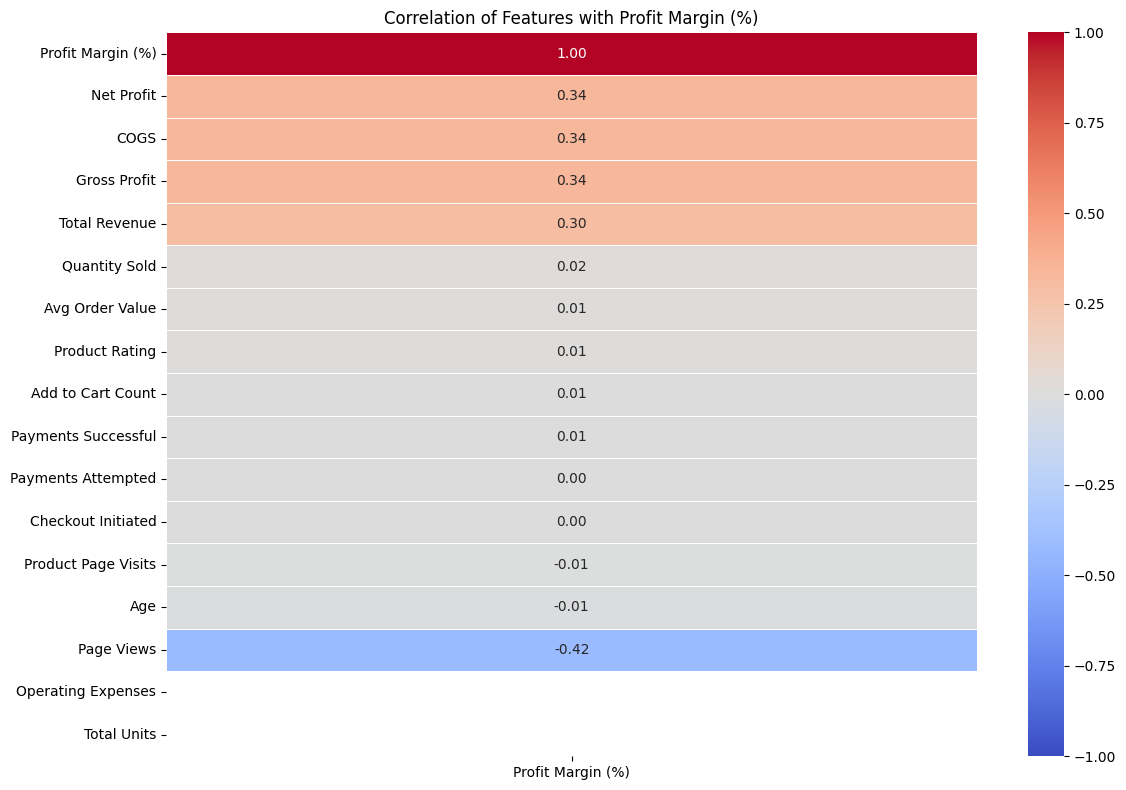

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure matplotlib displays inline
%matplotlib inline

# Loading the dataset (assuming it's accessible as a file)
data = pd.read_csv('formatting_data.csv')

# Selecting numerical columns for correlation analysis
numerical_columns = [
    'Profit Margin (%)', 'Age', 'Page Views', 'Product Rating',
    'Total Revenue', 'Gross Profit', 'Net Profit', 'COGS',
    'Operating Expenses', 'Avg Order Value', 'Product Page Visits',
    'Add to Cart Count', 'Checkout Initiated', 'Payments Attempted',
    'Payments Successful', 'Quantity Sold', 'Total Units'
]

# Ensuring the selected columns exist in the dataset
numerical_columns = [col for col in numerical_columns if col in data.columns]

# Converting columns to numeric, handling errors by coercing to NaN
for col in numerical_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Dropping rows with NaN values in the selected columns
data_clean = data[numerical_columns].dropna()

# Calculating the correlation matrix
correlation_matrix = data_clean.corr()

# Extracting correlations with 'Profit Margin (%)'
profit_margin_corr = correlation_matrix['Profit Margin (%)'].sort_values(ascending=False)

# Printing the top 5 positive and top 5 negative correlations
print("Top 5 Positive Correlations with Profit Margin (%):")
print(profit_margin_corr.head(6)[1:])  # Excluding self-correlation
print("\nTop 5 Negative Correlations with Profit Margin (%):")
print(profit_margin_corr.tail(5))

# Creating a heatmap for correlations with 'Profit Margin (%)'
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix[['Profit Margin (%)']].sort_values(by='Profit Margin (%)', ascending=False),
    annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', linewidths=0.5
)
plt.title('Correlation of Features with Profit Margin (%)')
plt.tight_layout()
plt.show()

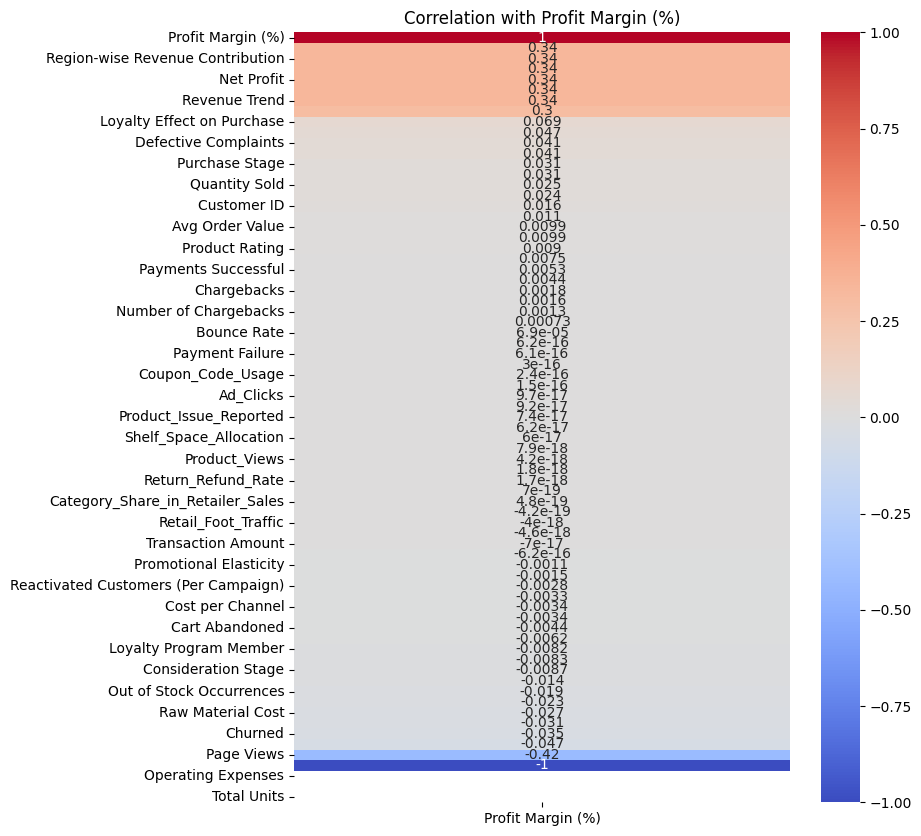


Strong Correlations (|corr| > 0.5):
Profit Margin (%)    1.0
Expense Breakdown   -1.0
Name: Profit Margin (%), dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(



Mutual Information Scores:
Expense Breakdown                   0.929
COGS                                0.925
Region-wise Revenue Contribution    0.925
Engagement Score                    0.925
Net Profit                          0.924
                                    ...  
Subscription Cancelled              0.012
Total Units                         0.008
Gross vs Net Profit                 0.000
Operating Expenses                  0.000
#Fraud Flag                         0.000
Length: 72, dtype: float64

Permutation Importance Scores:
Expense Breakdown                   0.531
Region-wise Revenue Contribution    0.018
COGS                                0.016
Revenue Trend                       0.015
Engagement Score                    0.013
                                    ...  
Product Rating                     -0.000
Purchase Stage                     -0.000
Page Views                         -0.000
Zip Code                           -0.000
Total Revenue                  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

# Load data
data = pd.read_csv('formatting_data.csv')

# Get numerical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Check if Profit Margin (%) exists
if 'Profit Margin (%)' not in num_cols:
    print("Error: 'Profit Margin (%)' not found. Columns:", num_cols)
    exit()

# Fill missing values with median
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# --- Correlation ---
# Calculate correlations
corr_matrix = data[num_cols].corr()

# Get correlations with Profit Margin (%)
profit_margin_corrs = corr_matrix['Profit Margin (%)'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(profit_margin_corrs.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Profit Margin (%)')
plt.show()

# Print strong correlations
print("\nStrong Correlations (|corr| > 0.5):")
print(profit_margin_corrs[abs(profit_margin_corrs) > 0.5].round(3))

# --- Mutual Information ---
# Features and target
X = data[num_cols].drop('Profit Margin (%)', axis=1)
y = data['Profit Margin (%)']

# Discretize Profit Margin (%) for MI
y_binned = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile').fit_transform(y.values.reshape(-1, 1)).ravel()

# Calculate MI
mi_scores = mutual_info_classif(X, y_binned, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Print MI
print("\nMutual Information Scores:")
print(mi_scores.round(3))

# --- Permutation Importance ---
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Calculate permutation importance
perm_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

# Print permutation importance
print("\nPermutation Importance Scores:")
print(perm_scores.round(3))

# Top 5 for each
print("\nTop 5 Correlations:")
print(profit_margin_corrs.head(5).round(3))
print("\nTop 5 Mutual Information:")
print(mi_scores.head(5).round(3))
print("\nTop 5 Permutation Importance:")
print(perm_scores.head(5).round(3))